In [ ]:
# ============================================================
# Task 2: Customer Segmentation Using Unsupervised Learning
# ============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
# ============================================================
# 1. Load Dataset
# ============================================================


In [3]:
df = pd.read_csv("Mall_Customers.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


First 5 Rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None

Statistica

In [ ]:
# ============================================================
# 2. Rename Column
# ============================================================

In [4]:
# Some datasets use "Genre" instead of "Gender"
df.rename(columns={"Genre": "Gender"}, inplace=True)

print("\nUpdated Columns:")
print(df.columns)


Updated Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [ ]:
# ============================================================
# 3. Exploratory Data Analysis
# ============================================================


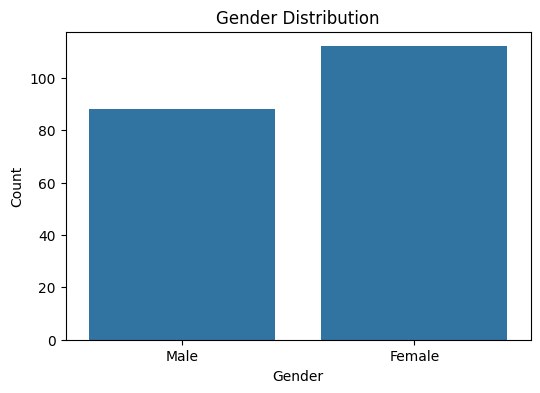

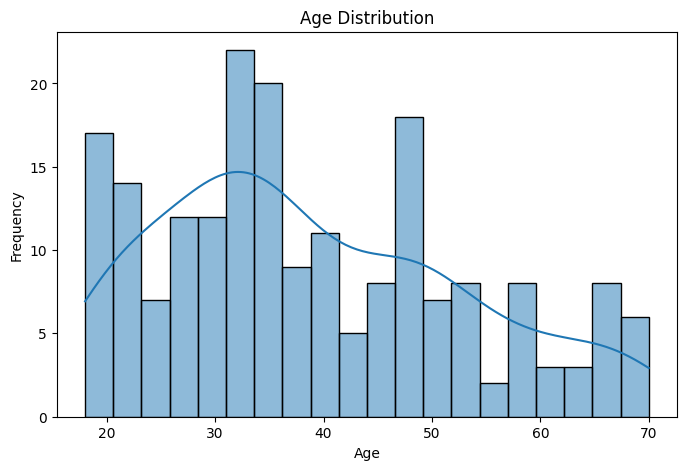

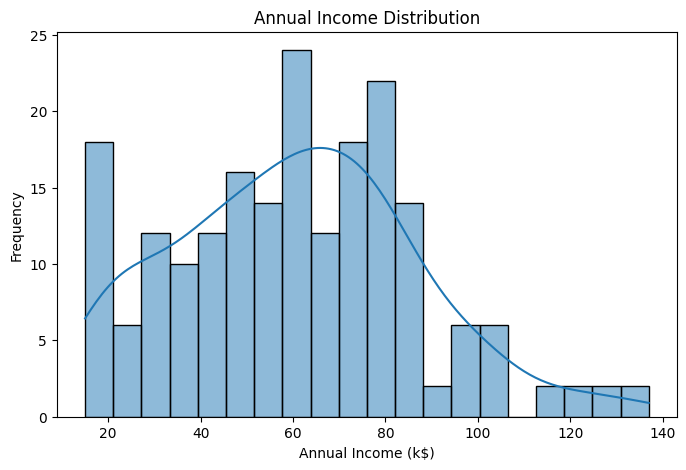

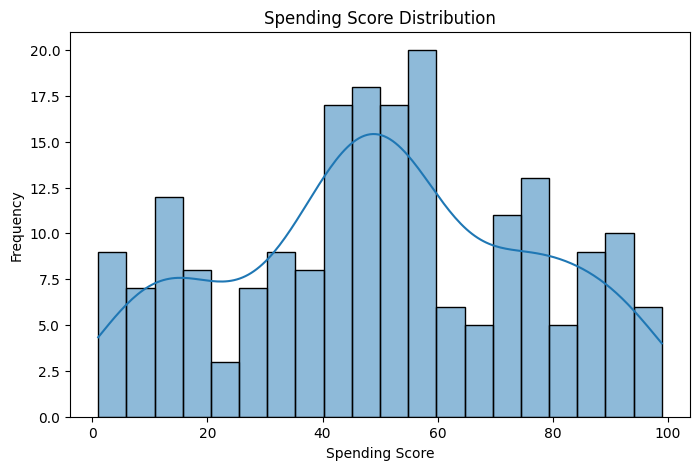

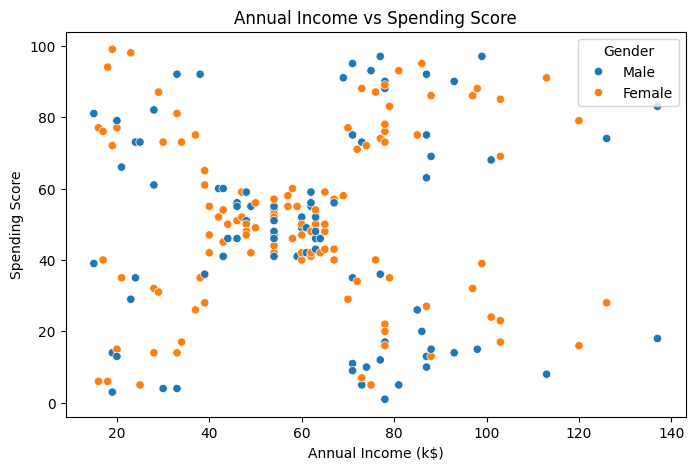

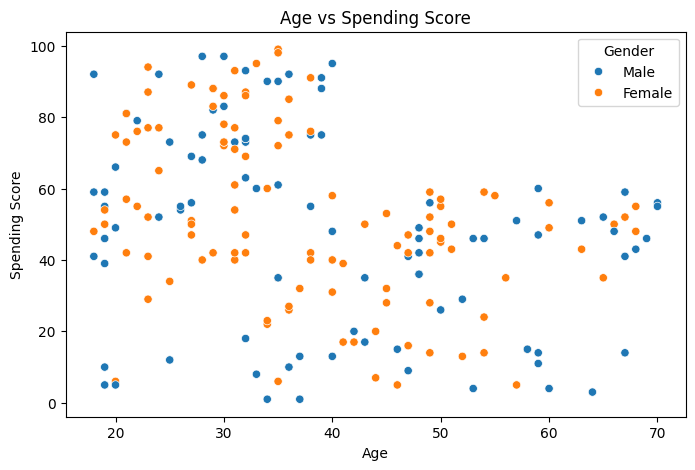

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    data=df
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    data=df
)
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

In [ ]:
# ============================================================
# 4. Encode Categorical Feature
# ============================================================

In [6]:
df_encoded = df.copy()

le = LabelEncoder()
df_encoded["Gender"] = le.fit_transform(df_encoded["Gender"])

print("\nEncoded Dataset:")
print(df_encoded.head())


Encoded Dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1       1   19                  15                      39
1           2       1   21                  15                      81
2           3       0   20                  16                       6
3           4       0   23                  16                      77
4           5       0   31                  17                      40


In [ ]:
# ============================================================
# 5. Correlation Heatmap
# ============================================================

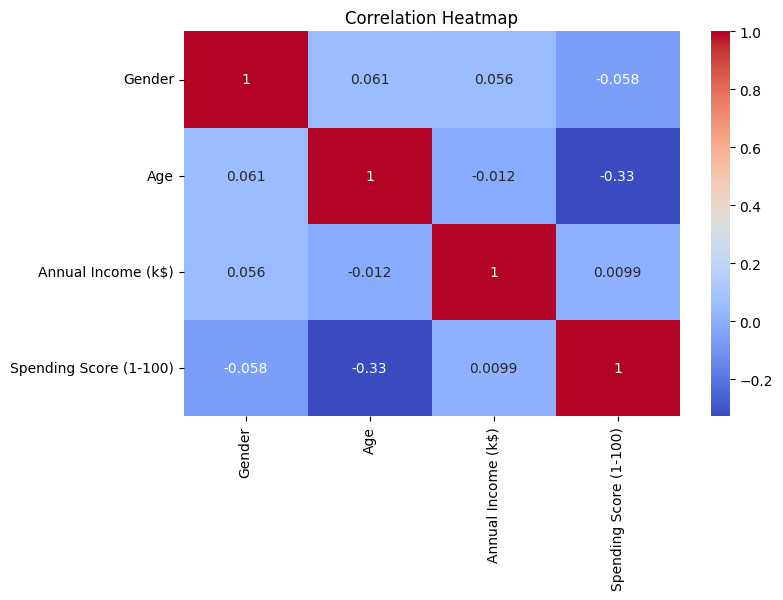

In [7]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_encoded.drop("CustomerID", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ============================================================
# 6. Feature Selection
# ============================================================

In [8]:
X = df_encoded[[
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

In [9]:
# ============================================================
# 7. Feature Scaling
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ============================================================
# 8. Elbow Method
# ============================================================


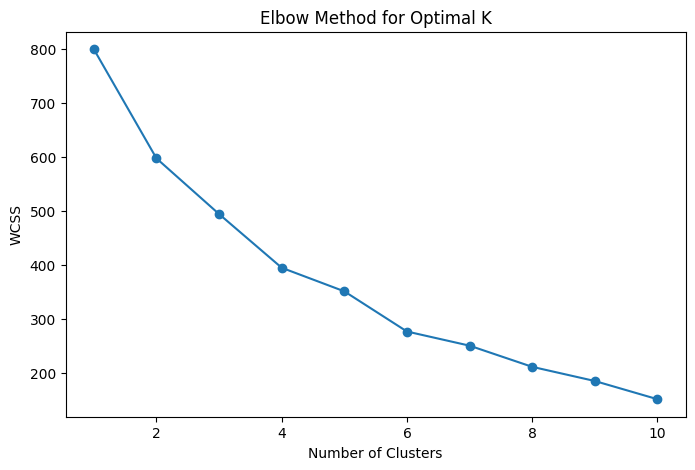

In [10]:

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [ ]:
# ============================================================
# 9. Silhouette Score
# ============================================================

Silhouette Score for k=2: 0.278
Silhouette Score for k=3: 0.258
Silhouette Score for k=4: 0.290
Silhouette Score for k=5: 0.272
Silhouette Score for k=6: 0.335
Silhouette Score for k=7: 0.346
Silhouette Score for k=8: 0.373
Silhouette Score for k=9: 0.388
Silhouette Score for k=10: 0.421


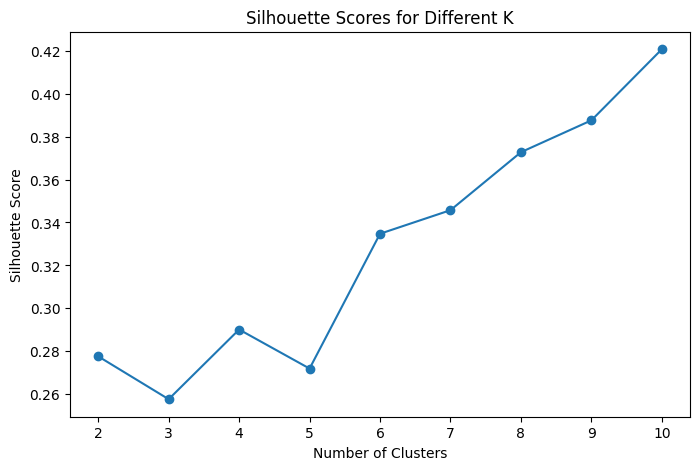

In [11]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for k={k}: {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
# ============================================================
# 10. Apply K-Means Clustering
# ============================================================

In [12]:
# Based on the common Mall Customers dataset pattern, k=5 is usually effective
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df_encoded["Cluster"] = df["Cluster"]

print("\nClustered Dataset:")
print(df.head())

print("\nCluster Counts:")
print(df["Cluster"].value_counts())



Clustered Dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        2  
2        4  
3        4  
4        4  

Cluster Counts:
Cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64


In [ ]:
# ============================================================
# 11. Cluster Visualization
# ============================================================

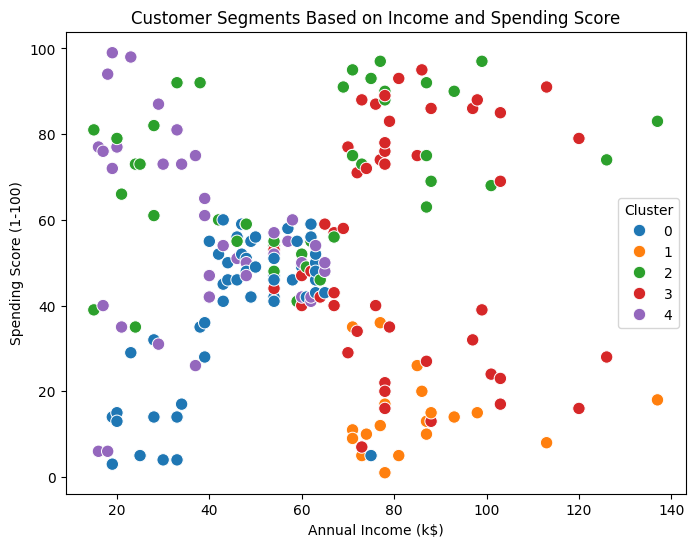

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    data=df,
    s=80
)

plt.title("Customer Segments Based on Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

In [ ]:
# ============================================================
# 12. PCA Visualization
# ============================================================

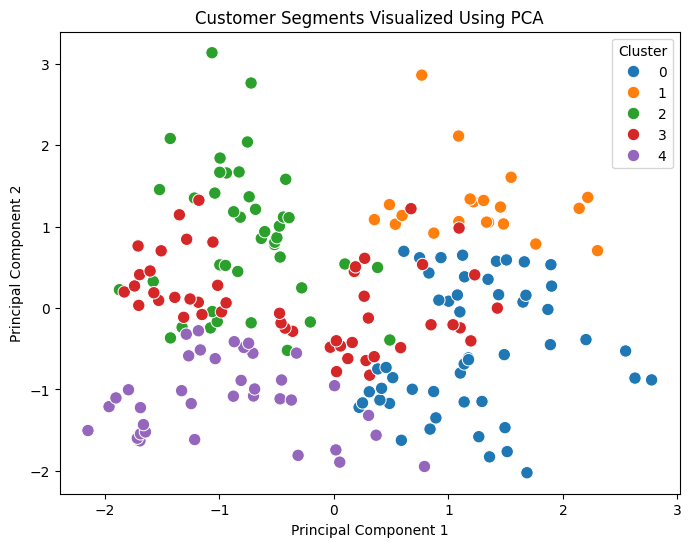

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    data=df,
    s=80
)

plt.title("Customer Segments Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [ ]:
# ============================================================
# 13. Cluster Analysis
# ============================================================



Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        56.470588           46.098039               39.313725
1        39.500000           85.150000               14.050000
2        28.690476           60.904762               70.238095
3        37.897959           82.122449               54.448980
4        27.315789           38.842105               56.210526


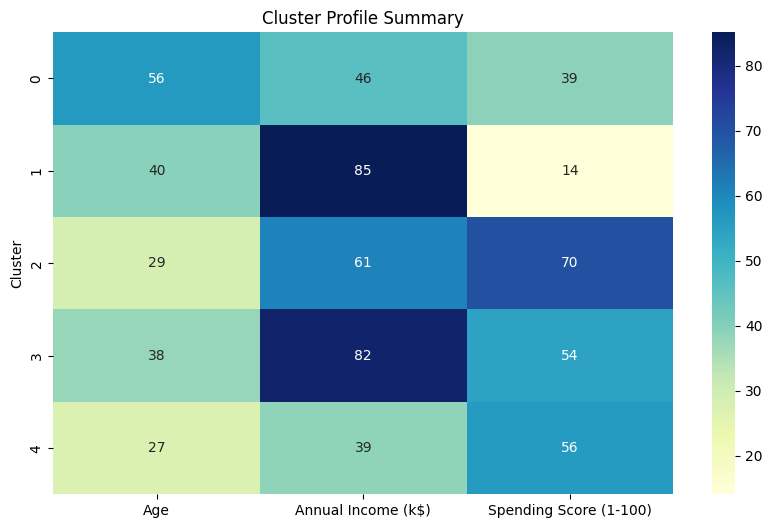

In [15]:

cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print("\nCluster Summary:")
print(cluster_summary)

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu"
)
plt.title("Cluster Profile Summary")
plt.show()

In [ ]:
# ============================================================
# 14. Marketing Strategies
# ============================================================

In [16]:
print("\n================ Marketing Strategies ================")

for cluster in cluster_summary.index:
    income = cluster_summary.loc[cluster, "Annual Income (k$)"]
    spending = cluster_summary.loc[cluster, "Spending Score (1-100)"]
    age = cluster_summary.loc[cluster, "Age"]

    print(f"\nCluster {cluster}:")
    print(f"Average Age: {age:.1f}")
    print(f"Average Income: {income:.1f}k$")
    print(f"Average Spending Score: {spending:.1f}")

    if income >= 60 and spending >= 60:
        print("Segment Type: High Income - High Spending")
        print("Strategy: Offer premium products, VIP memberships, and loyalty rewards.")

    elif income >= 60 and spending < 50:
        print("Segment Type: High Income - Low Spending")
        print("Strategy: Use personalized offers, exclusive discounts, and targeted campaigns.")

    elif income < 40 and spending >= 60:
        print("Segment Type: Low Income - High Spending")
        print("Strategy: Provide budget-friendly bundles, reward points, and seasonal discounts.")

    elif income < 40 and spending < 50:
        print("Segment Type: Low Income - Low Spending")
        print("Strategy: Promote affordable products and basic discount campaigns.")

    else:
        print("Segment Type: Average Income - Average Spending")
        print("Strategy: Use regular promotions, membership programs, and engagement campaigns.")


================ Marketing Strategies ================

Cluster 0:
Average Age: 56.5
Average Income: 46.1k$
Average Spending Score: 39.3
Segment Type: Average Income - Average Spending
Strategy: Use regular promotions, membership programs, and engagement campaigns.

Cluster 1:
Average Age: 39.5
Average Income: 85.2k$
Average Spending Score: 14.1
Segment Type: High Income - Low Spending
Strategy: Use personalized offers, exclusive discounts, and targeted campaigns.

Cluster 2:
Average Age: 28.7
Average Income: 60.9k$
Average Spending Score: 70.2
Segment Type: High Income - High Spending
Strategy: Offer premium products, VIP memberships, and loyalty rewards.

Cluster 3:
Average Age: 37.9
Average Income: 82.1k$
Average Spending Score: 54.4
Segment Type: Average Income - Average Spending
Strategy: Use regular promotions, membership programs, and engagement campaigns.

Cluster 4:
Average Age: 27.3
Average Income: 38.8k$
Average Spending Score: 56.2
Segment Type: Average Income - Average Sp

In [ ]:
# ============================================================
# 15. Conclusion
# ============================================================

# This project successfully applied K-Means Clustering to segment mall customers based on age, annual income, and spending behavior. 
# Exploratory Data Analysis provided valuable insights into customer characteristics
# while PCA was used to visualize customer segments effectively.
# Five distinct customer groups were identified, each exhibiting unique spending patterns and income levels. 
# These segments can help businesses develop targeted marketing campaigns, improve customer retention, and optimize promotional strategies. 
# Overall, customer segmentation provides valuable business intelligence that supports data-driven decision-making and enhances customer relationship management.